<a href="https://colab.research.google.com/github/sun-mengwei/dtb-colab-experiments/blob/codex%2Fgame-dynamics-dtb/DTB_Game_Ver2/cournot_10d_nonpotential_mlp_dtb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ten-player Cournot game: ordinary neural DTB map update

The notebook reuses `ResidualMLPMap`, `game_dtb_basis_matrices`, and `map_at` from `run_game_dtb.py`; `count_trainable` from `network.py`; and `device`, `flat_params`, and `jform_solve` from `dtb.py`.

Plots are generated by the reusable `game_visualization.py` utility. It infers the state dimension and supports NumPy arrays or PyTorch tensors.

The notebook follows four blocks: **define the game velocity**, **initialize an MLP tangent representation**, **update the pushforward map**, and **save diagnostics and plots**.

Use a fixed sample of labels \(z_j\) and initialize \(X_0(z)=z\). The MLP \(f_{\theta_0}:\mathbb{R}^{10}\to\mathbb{R}^{10}\) supplies the tangent basis; it is separate from the evolving map \(X_k\). Its parameters stay fixed in this map-only experiment, and all MLP parameters enter the tangent representation.

At each step, evaluate the parameter Jacobian at the **current physical points**:

\[
x_{k,j}=X_k(z_j),\qquad J_{k,j}=\partial_\theta f_{\theta_0}(x_{k,j}),\qquad
g_{k,j}=b(x_{k,j}).
\]

Solve the tangent projection and update the map:

\[
\alpha_k=\arg\min_\alpha\frac1N\sum_j\|J_{k,j}\alpha-g_{k,j}\|^2,
\qquad u_k(x)=\partial_\theta f_{\theta_0}(x)\alpha_k,
\qquad X_{k+1}(z)=X_k(z)+h\,u_k(X_k(z)).
\]

The normal equations are \(G_k\alpha_k=P_k\), with \(G_k=N^{-1}\sum_jJ_{k,j}^{\mathsf T}J_{k,j}\) and \(P_k=N^{-1}\sum_jJ_{k,j}^{\mathsf T}g_{k,j}\). The code solves the equivalent stacked least-squares problem with a truncated SVD. The common \(1/N\) factor does not change the solution. The Jacobian and its SVD are rebuilt each step because the physical points move.

This is the fixed-sample, deterministic variant: labels are drawn once, the target velocity is just \(b(x)\), and every map step uses the tangent projection. All diagnostics use the actual DTB trajectory.

In [5]:
# BLOCK 1 — Define the ten-player velocity field and experiment controls.
from pathlib import Path
from itertools import combinations
import csv
import json
import time
import subprocess
import sys
import numpy as np
import torch
from torch.func import jvp

# Use sibling repository modules locally; fetch the same branch in Colab.
module_files = ('run_game_dtb.py', 'network.py', 'dtb.py', 'game_visualization.py')
EXPERIMENT_DIR = next((folder for folder in (Path.cwd(), Path.cwd() / 'DTB_Game_Ver2')
                       if all((folder / name).is_file() for name in module_files)), None)
if EXPERIMENT_DIR is None:
    if not Path('/content').is_dir():
        raise FileNotFoundError('Run this notebook from the repository root or DTB_Game_Ver2 directory.')
    repo = Path('/content/dtb-colab-experiments')
    if not (repo / '.git').exists():
        subprocess.run(['git', 'clone', '--depth', '1', '--branch', 'codex/game-dynamics-dtb',
                        'https://github.com/sun-mengwei/dtb-colab-experiments.git', str(repo)], check=True)
    else:
        subprocess.run(['git', '-C', str(repo), 'checkout', 'codex/game-dynamics-dtb'], check=True)
        subprocess.run(['git', '-C', str(repo), 'pull', '--ff-only'], check=True)
    EXPERIMENT_DIR = repo / 'DTB_Game_Ver2'
sys.path.insert(0, str(EXPERIMENT_DIR.resolve()))

from run_game_dtb import ResidualMLPMap, game_dtb_basis_matrices, map_at
from network import count_trainable
from dtb import device, flat_params, jform_solve
from game_visualization import save_game_visualizations

SEED = 2026
DIM = 3
N_PARTICLES = 384
T_FINAL, H = 1.0, 0.01
N_STEPS = round(T_FINAL / H)
MLP_WIDTH, MLP_DEPTH = 24, 2
JACOBIAN_CHUNK = 64
SVD_RTOL = 1e-3
INITIAL_TOTAL = 1.0
COURNOT_B, COURNOT_MU = 1.0, 2.0
OUTPUT_DIR = Path('cournot_10d_dtb_outputs')
DEVICE = device()
DTYPE = torch.float32
assert N_STEPS > 0 and H > 0 and np.isclose(N_STEPS * H, T_FINAL)
torch.manual_seed(SEED)
if DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(SEED)

def cournot_velocity(x):
    """b_i(x) = 2 B [max(mu r_i (1-r_i), 0) - x_i], r_i = sum_{j != i} x_j."""
    opponents = x.sum(dim=-1, keepdim=True) - x
    best_response = (COURNOT_MU * opponents * (1.0 - opponents)).clamp_min(0.0)
    return 2.0 * COURNOT_B * (best_response - x)

# Analytic reference points for read-only equilibrium-distance diagnostics.
# This is a known subset of equilibria, not an exhaustive classification.
known_points = [torch.zeros(DIM, device=DEVICE, dtype=DTYPE)]
known_names = ['origin']
q = (COURNOT_MU * (DIM - 1) - 1.0) / (COURNOT_MU * (DIM - 1) ** 2)
if q > 0:
    known_points.append(torch.full((DIM,), q, device=DEVICE, dtype=DTYPE))
    known_names.append('symmetric')
if COURNOT_MU == 2.0:
    for first, second in combinations(range(DIM), 2):
        point = torch.zeros(DIM, device=DEVICE, dtype=DTYPE)
        point[first] = point[second] = 0.5
        known_points.append(point)
        known_names.append(f'pair({first + 1},{second + 1})')
known_equilibria = torch.stack(known_points)
assert torch.linalg.vector_norm(cournot_velocity(known_equilibria), dim=1).max() < 2e-5
print({'device': str(DEVICE), 'players': DIM, 'particles': N_PARTICLES,
       'steps': N_STEPS, 'final_time': T_FINAL})

{'device': 'cuda', 'players': 3, 'particles': 384, 'steps': 100, 'final_time': 1.0}


In [6]:
# BLOCK 2 — Initialize X_0(z)=z and the MLP used to generate the tangent plane.
# Draw labels once. These same labels are used throughout the experiment.
weights = -torch.rand(N_PARTICLES, DIM, device=DEVICE, dtype=DTYPE).clamp_min(1e-7).log()
labels = INITIAL_TOTAL * weights / weights.sum(dim=1, keepdim=True)
x_0 = labels.clone()

# Reuse the existing MLP architecture; X_0 remains the identity independently.
mlp = ResidualMLPMap(
    dim=DIM, width=MLP_WIDTH, depth=MLP_DEPTH, activation='tanh',
    dtype=DTYPE, zero_init_output=False,
).net.to(DEVICE)
N_PARAMETERS = count_trainable(mlp)
theta_0, structure, _ = flat_params(mlp)
parameter_names = [name for name, _ in structure]
parameter_shapes = [shape for _, shape in structure]
# The shared Jacobian helper accepts selected coordinates; use all of them.
selected = torch.arange(N_PARAMETERS, device=DEVICE)
mlp.requires_grad_(False)

@torch.no_grad()
def evaluate_map(initial_points, coefficients, theta):
    """Replay the composed map X_k on any input labels, using stored alpha_0,...,alpha_{k-1}."""
    current = initial_points.to(device=DEVICE, dtype=DTYPE).clone()
    for alpha in coefficients:
        alpha = alpha.to(device=DEVICE, dtype=DTYPE)
        _, velocity = jvp(lambda parameters: map_at(parameters, current, mlp, structure),
                          (theta,), (alpha,))
        current = current + H * velocity
    return current

print({'MLP': str(mlp), 'all_tangent_parameters': N_PARAMETERS,
       'stacked_J_shape': (N_PARTICLES * DIM, N_PARAMETERS)})

{'MLP': 'Sequential(\n  (0): Linear(in_features=3, out_features=24, bias=True)\n  (1): Tanh()\n  (2): Linear(in_features=24, out_features=24, bias=True)\n  (3): Tanh()\n  (4): Linear(in_features=24, out_features=3, bias=True)\n)', 'all_tangent_parameters': 771, 'stacked_J_shape': (1152, 771)}


In [7]:
# BLOCK 3 — Update the map using its tangent velocity and record each step.
def synchronize():
    if DEVICE.type == 'cuda':
        torch.cuda.synchronize()

def rms_vector(values):
    return values.square().sum(dim=-1).mean().sqrt()

def state_diagnostics(points, step):
    nearest = torch.cdist(points, known_equilibria).min(dim=1).values
    return {
        'step': step, 'time': step * H,
        'game_drift_rms': float(rms_vector(cournot_velocity(points))),
        'median_known_distance': float(nearest.median()),
        'p90_known_distance': float(torch.quantile(nearest, 0.9)),
        'minimum_coordinate': float(points.min()),
        'negative_coordinate_fraction': float((points < 0).float().mean()),
    }

def solve_projection(A, target):
    """Use the shared DTB solver, then measure the projection residual."""
    alpha = jform_solve(A, target, rtol=SVD_RTOL, method='svd_gpu')
    residual = A @ alpha - target
    return alpha, {
        'projection_residual': float(residual.norm() / target.norm().clamp_min(1e-30)),
        'alpha_norm': float(alpha.norm()),
    }

@torch.no_grad()
def run_dtb(initial_points, theta):
    current = initial_points.clone()
    trajectory = [current.cpu()]
    coefficients = []
    states = [state_diagnostics(current, 0)]
    projections = []
    synchronize()
    run_start = time.perf_counter()

    for step in range(N_STEPS):
        # x_{k,j} = X_k(z_j); target g_{k,j} = b(x_{k,j}).
        target = cournot_velocity(current)
        synchronize()
        basis_start = time.perf_counter()
        _, J, A = game_dtb_basis_matrices(
            theta, selected, current, mlp, structure, chunk=JACOBIAN_CHUNK
        )
        synchronize()
        solve_start = time.perf_counter()

        # This solves G_k alpha_k = P_k through its stacked least-squares form.
        alpha, info = solve_projection(A, target.reshape(-1))
        synchronize()
        update_start = time.perf_counter()

        # u_k(X_k(z)) = J_theta(X_k(z)) alpha_k; update the map at the fixed labels.
        projected_velocity = (A @ alpha).reshape_as(current)
        current = current + H * projected_velocity
        if not torch.isfinite(current).all():
            raise FloatingPointError(f'Non-finite DTB state at step {step + 1}')
        synchronize()
        update_end = time.perf_counter()

        coefficients.append(alpha.cpu())
        trajectory.append(current.cpu())
        states.append(state_diagnostics(current, step + 1))
        projections.append({
            'step': step, 'time': step * H, **info,
            'projected_drift_rms': float(rms_vector(projected_velocity)),
            'basis_seconds': solve_start - basis_start,
            'solve_seconds': update_start - solve_start,
            'update_seconds': update_end - update_start,
        })
        if (step + 1) % max(1, N_STEPS // 10) == 0:
            print(f"step {step + 1}/{N_STEPS}: projection residual={info['projection_residual']:.3e}, "
                  f"endpoint drift RMS={states[-1]['game_drift_rms']:.3e}")

    synchronize()
    return {'trajectory': torch.stack(trajectory),
            'coefficients': torch.stack(coefficients),
            'states': states, 'projections': projections,
            'wall_seconds': time.perf_counter() - run_start}

result = run_dtb(x_0, theta_0)
trajectory = result['trajectory']
dtb_endpoints = trajectory[-1]
print({'DTB_wall_seconds': result['wall_seconds'], **result['states'][-1]})

# The global map is available on new labels as well as the stored particles:
# new_endpoints = evaluate_map(new_labels, result['coefficients'], theta_0)
# For X_k, pass result['coefficients'][:k] instead.

step 10/100: projection residual=9.586e-02, endpoint drift RMS=4.934e-01
step 20/100: projection residual=1.649e-01, endpoint drift RMS=3.882e-01
step 30/100: projection residual=1.691e-01, endpoint drift RMS=3.032e-01
step 40/100: projection residual=1.894e-01, endpoint drift RMS=2.370e-01
step 50/100: projection residual=2.569e-01, endpoint drift RMS=1.885e-01
step 60/100: projection residual=3.128e-01, endpoint drift RMS=1.540e-01
step 70/100: projection residual=3.826e-01, endpoint drift RMS=1.295e-01
step 80/100: projection residual=4.597e-01, endpoint drift RMS=1.119e-01
step 90/100: projection residual=5.440e-01, endpoint drift RMS=9.926e-02
step 100/100: projection residual=6.637e-01, endpoint drift RMS=9.066e-02
{'DTB_wall_seconds': 19.27604959300004, 'step': 100, 'time': 1.0, 'game_drift_rms': 0.0906635969877243, 'median_known_distance': 0.15332205593585968, 'p90_known_distance': 0.21925491094589233, 'minimum_coordinate': -0.05215034261345863, 'negative_coordinate_fraction': 

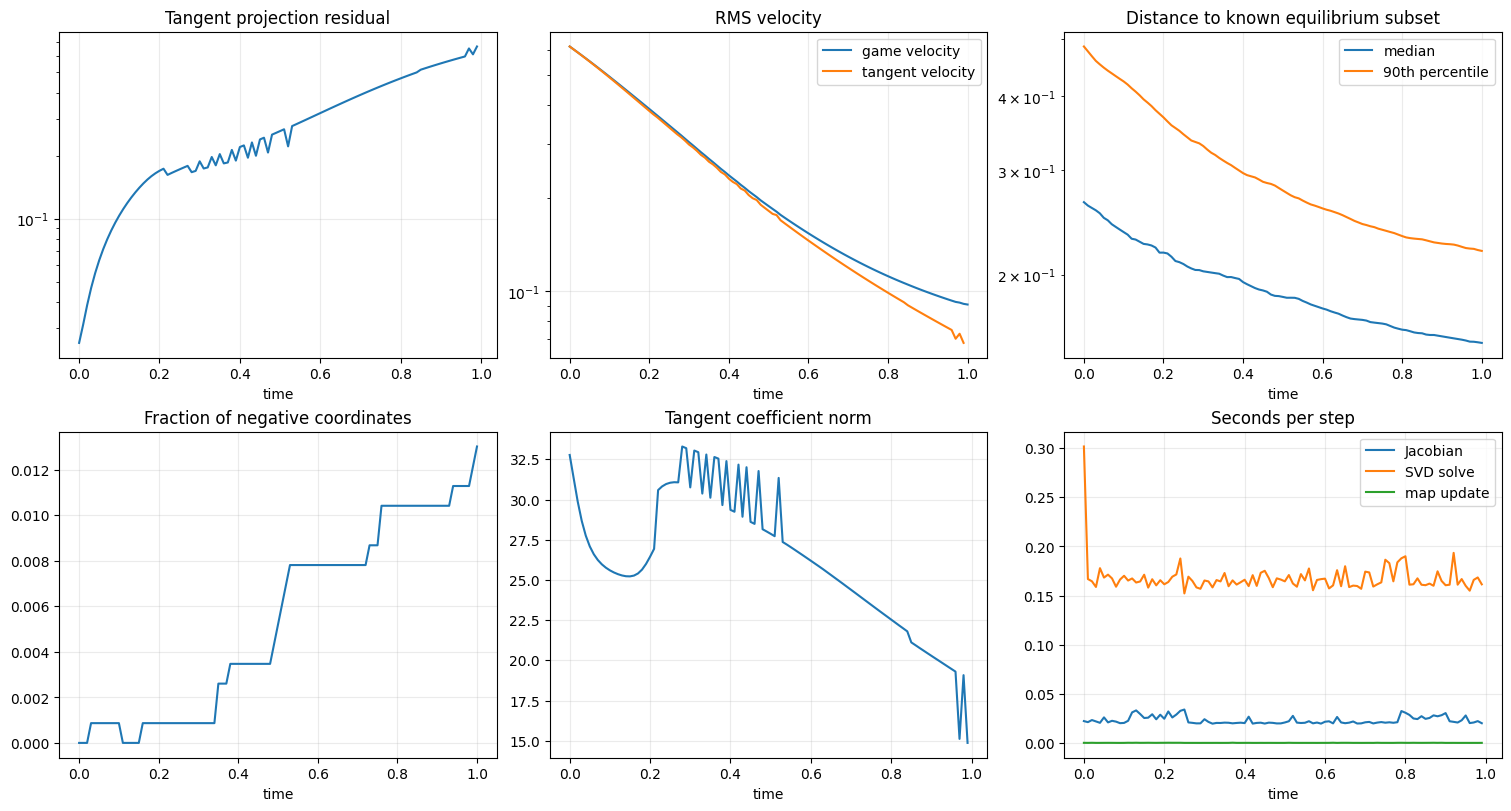

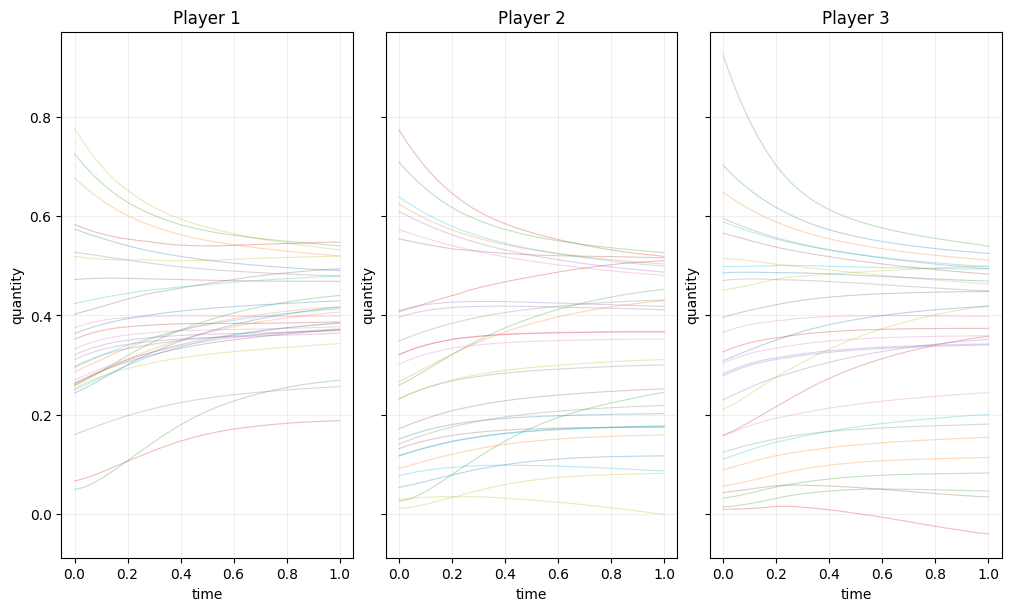

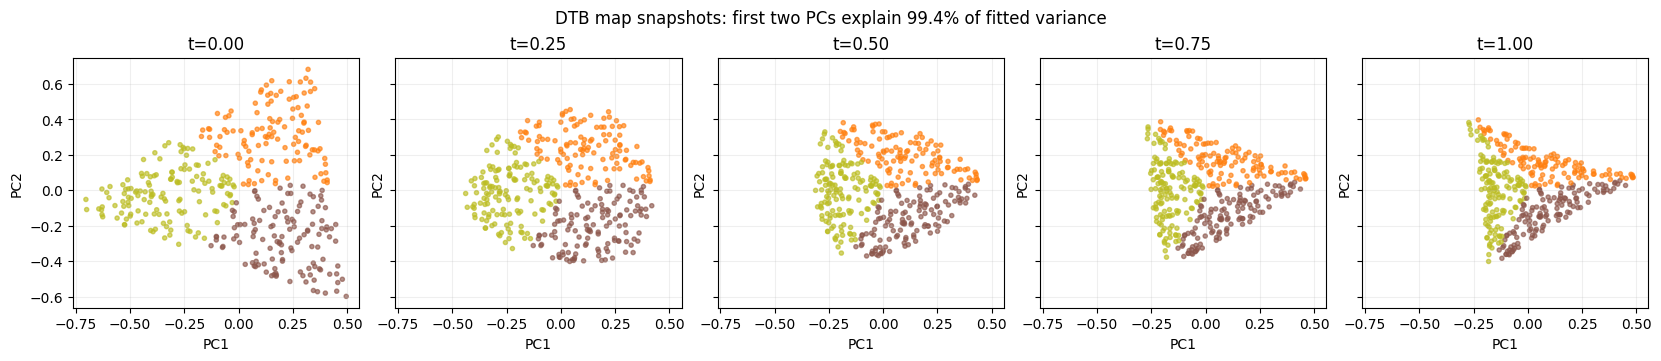

Saved map state, trajectory, diagnostics, and plots to: /content/cournot_10d_dtb_outputs


In [8]:
# BLOCK 4 — Save the DTB map, trajectory, diagnostics, and plots.
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def save_table(filename, rows):
    with (OUTPUT_DIR / filename).open('w', newline='') as handle:
        writer = csv.DictWriter(handle, fieldnames=list(rows[0]))
        writer.writeheader()
        writer.writerows(rows)

save_table('state_diagnostics.csv', result['states'])
save_table('projection_diagnostics.csv', result['projections'])
configuration = {
    'seed': SEED, 'dim': DIM, 'particles': N_PARTICLES, 'steps': N_STEPS,
    'h': H, 'final_time': T_FINAL, 'mlp_width': MLP_WIDTH, 'mlp_depth': MLP_DEPTH,
    'svd_rtol': SVD_RTOL, 'initial_total': INITIAL_TOTAL,
    'cournot_b': COURNOT_B, 'cournot_mu': COURNOT_MU,
    'jacobian_chunk': JACOBIAN_CHUNK, 'dtype': str(DTYPE), 'device': str(DEVICE),
    'tangent_parameters': N_PARAMETERS, 'wall_seconds': result['wall_seconds'],
}
(OUTPUT_DIR / 'configuration.json').write_text(json.dumps(configuration, indent=2) + '\n')
torch.save({
    'configuration': configuration, 'theta_0': theta_0.cpu(),
    'parameter_names': parameter_names, 'parameter_shapes': parameter_shapes,
    'labels': labels.cpu(), 'trajectory': trajectory, 'coefficients': result['coefficients'],
    'known_equilibria': known_equilibria.cpu(), 'known_names': known_names,
}, OUTPUT_DIR / 'dtb_run.pt')

# Defaults show (x1, x2) and, when available, (x3, x4), at five times.
# For other planes, pass coordinate_pairs=[(1, 3), (2, 5)] (one-based indices).
visualizations = save_game_visualizations(
    trajectory, h=H, output_dir=OUTPUT_DIR,
    equilibria=known_equilibria, equilibrium_names=known_names,
    equilibrium_radius=0.05,
    feasible_mask=(trajectory >= 0).all(dim=-1),
    state_diagnostics=result['states'], projection_diagnostics=result['projections'],
)
print('Saved map, trajectory, diagnostics, and visualizations to:', OUTPUT_DIR.resolve())


The initial label distribution is sampled once on the simplex. Each subsequent state is produced by the ordinary tangent-bundle map update. The MLP parameters remain \(\theta_0\), while \(J_{k,j}=\partial_\theta f_{\theta_0}(X_k(z_j))\) changes with the physical points. There is no optimizer step on the MLP.

`dtb_run.pt` stores the initial labels, frozen MLP parameters, all tangent coefficients, and the full particle trajectory. Together with the saved configuration, the coefficients specify the composed global map. `evaluate_map` applies that map to arbitrary input labels. During the run, the fixed projection particles also serve as diagnostic particles.

`state_diagnostics.csv` includes the initial state and every updated state. `projection_diagnostics.csv` records each tangent solve at its input time \(t_k\). Endpoint residuals and distances are measured at \(T_{\mathrm{FINAL}}\); particle coordinates are kept exactly as produced by DTB. A small projected velocity alone does not establish equilibrium when the game-velocity residual is large. Coordinate snapshots show the actual player quantities in the (x1, x2) and (x3, x4) planes, with the same axis limits across time, projected reference equilibria, and short trails for fixed particles. These views can overlap in hidden coordinates; equilibrium distances use the full state.

Increase `T_FINAL` to study longer-time behavior using the same map update. The shared solver returns tangent coefficients; the notebook records their norm and the projection residual without performing a second SVD for rank diagnostics. Both the explicit parameter Jacobian and its SVD are recomputed every step, so `N_PARTICLES` and `MLP_WIDTH` affect runtime and memory.

The visualization utility also writes:

- `state_heatmaps.png`: every player coordinate for each displayed particle. Rows are ordered once by final-state similarity and kept fixed across times; all panels share one color scale. Up to 512 particles are shown by default, and the original particle IDs are saved.
- `equilibrium_pair_occupancy.png`: the fraction of all particles near each two-coordinate support equilibrium, for each snapshot. The matrix size follows the game dimension. Other equilibrium families are included in the occupancy-over-time plot.
- `equilibrium_occupancy_over_time.png`: neighborhood occupancy by equilibrium family, with unassigned particles shown explicitly.
- `equilibrium_occupancy.csv` and `visualization_data.npz`: per-equilibrium counts and fractions at every time, full-state assignments/distances, and the fixed heatmap ordering.

`equilibrium_radius=0.05` is a Euclidean distance in the full state space and can be changed in the visualization call. For this Cournot experiment, negative-coordinate particles remain unassigned through `feasible_mask`; their actual values remain visible in the coordinate plots and heatmaps. Occupancy measures proximity, not convergence or basin membership. The utility accepts other games' reference equilibria and an optional feasibility mask; it does not assume that every game has pair equilibria.

For a 3D, 5D, or 6D experiment, the same visualization call works with the corresponding trajectory and reference points. Change `coordinate_pairs`, `snapshot_steps`, or `equilibrium_radius` only when desired; no plotting implementation needs to be copied into the notebook.
